
# Analysis and Plots for Final Report (V20)
This notebook generates the plots for the final report based on the optimal model (V20).


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import f1_score
from nltk.stem import SnowballStemmer

%matplotlib inline
os.makedirs('final_img', exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# Load Data
df = pd.read_csv("winter_project_2026/development.csv")
print(f"Loaded dataset with {len(df)} samples")


Loaded dataset with 79997 samples



## 1. Label Distribution
Verifying class imbalance.


/var/folders/j9/m1q0h7955ls67lg17_lw___80000gn/T/ipykernel_74025/3761394648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis')


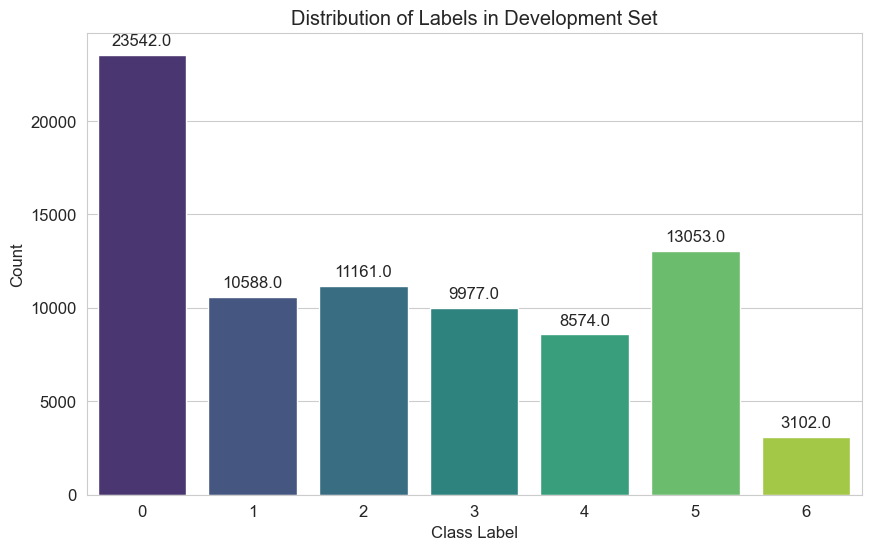

In [2]:

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Labels in Development Set')
plt.xlabel('Class Label')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.savefig('final_img/plot_label_distribution.pdf', format='pdf', bbox_inches='tight')
plt.savefig('final_img/plot_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



## 2. Analysis of Chosen "Pure" Sources
We visualize the label distribution ONLY for the sources we selected for boosting in V20.
This justifies why we boosted them x4.


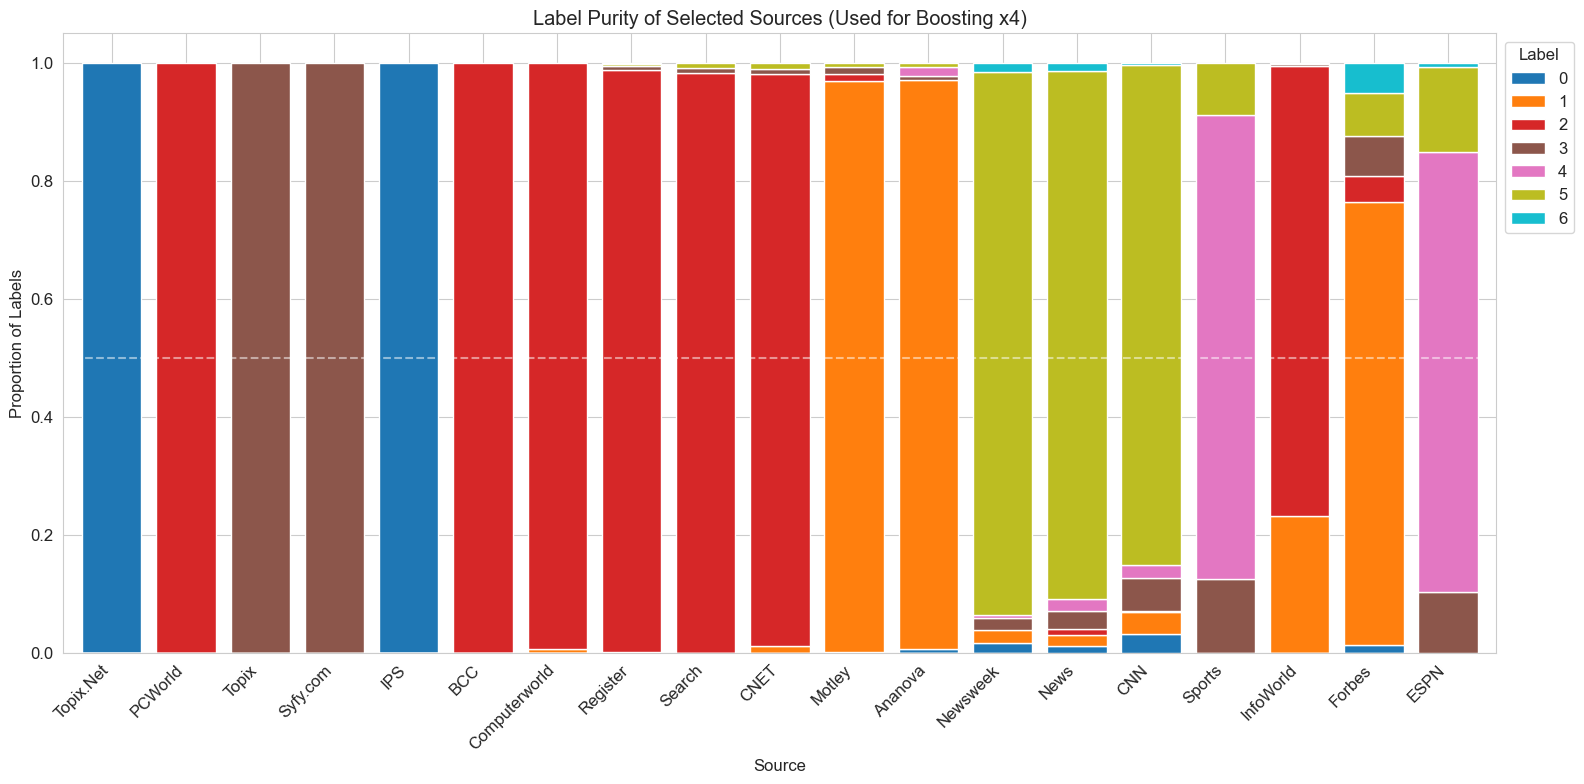

In [3]:

# The exact list used in V20
chosen_pure_sources = [
    'Syfy.com', 'Topix', 'PCWorld', 'BCC', 'Computerworld', 
    'Register', 'Search', 'CNET', 'InfoWorld', 'IPS', 'Topix.Net',
    'Motley', 'Ananova', 'Forbes', 'Newsweek', 'News', 'CNN',
    'Sports', 'ESPN'
]

# Filter df for these sources
mask = df['source'].isin(chosen_pure_sources)
df_pure = df[mask]

# Create Crosstab (normalized to show percentage purity)
source_dist = pd.crosstab(df_pure['source'], df_pure['label'], normalize='index')

# Sort by the max class probability for better visualization
source_dist['max_val'] = source_dist.max(axis=1)
source_dist = source_dist.sort_values('max_val', ascending=False).drop('max_val', axis=1)

# Plot
ax = source_dist.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='tab10', width=0.8)
plt.title('Label Purity of Selected Sources (Used for Boosting x4)')
plt.xlabel('Source')
plt.ylabel('Proportion of Labels')
plt.legend(title='Label', bbox_to_anchor=(1.0, 1), loc='upper left')
plt.axhline(y=0.5, color='white', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('final_img/plot_pure_sources.pdf', format='pdf', bbox_inches='tight')
plt.savefig('final_img/plot_pure_sources.png', dpi=300, bbox_inches='tight')
plt.show()



## 3. Alpha Optimization Curve (Full V20 Model)
Analyzing sensitivity to regularization using the COMPLETE V20 pipeline (100k Features, Char N-grams, etc.).


Training Full V20 models for Alpha Curve (this may take a minute)...
Testing alpha=0.001...


/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


-> Macro F1: 0.7044
Testing alpha=0.0001...


/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


-> Macro F1: 0.7262
Testing alpha=7e-05...


...

-> Macro F1: 0.7244
Testing alpha=5e-05...


/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


-> Macro F1: 0.7221
Testing alpha=1e-05...


/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


-> Macro F1: 0.7078


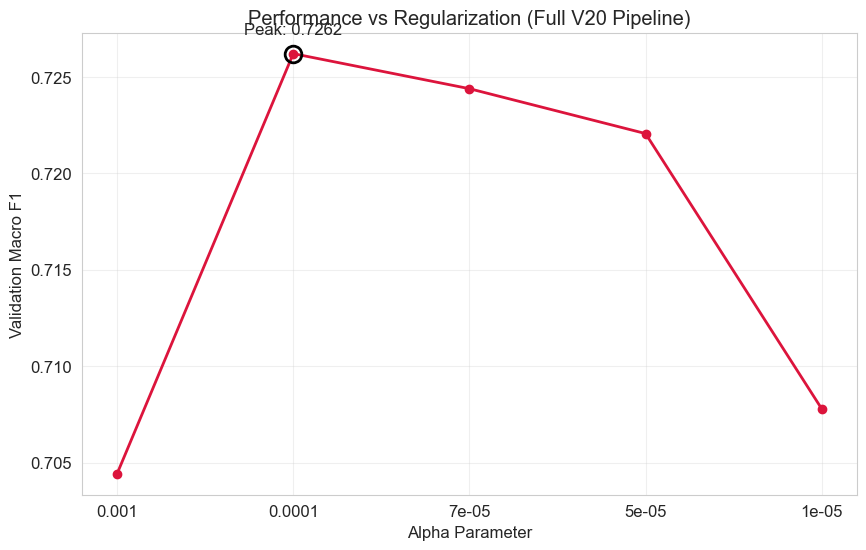

In [4]:

# --- V20 Components ---
stemmer = SnowballStemmer("english")
def stemmed_tokenizer(text):
    tokens = re.findall(r'(?u)\b\w\w+\b', text)
    return [stemmer.stem(t) for t in tokens]

def preprocess_v20(df):
    df = df.copy()
    # FillNA
    df['title'] = df['title'].fillna('')
    df['article'] = df['article'].fillna('')
    df['source'] = df['source'].fillna('Unknown')
    
    # Source Boosting Logic
    pure_sources = [
        'Syfy.com', 'Topix', 'PCWorld', 'BCC', 'Computerworld', 
        'Register', 'Search', 'CNET', 'InfoWorld', 'IPS', 'Topix.Net',
        'Motley', 'Ananova', 'Forbes', 'Newsweek', 'News', 'CNN',
        'Sports', 'ESPN'
    ]
    s = df['source']
    t = df['title']
    a = df['article']
    
    # x4 Boosting
    text_boosted = s + ' ' + s + ' ' + s + ' ' + s + ' ' + t + ' ' + t + ' ' + t + ' ' + t + ' ' + a + ' ' + a
    text_standard = s + ' ' + s + ' ' + t + ' ' + t + ' ' + t + ' ' + a + ' ' + a
    df['text'] = np.where(df['source'].isin(pure_sources), text_boosted, text_standard)
    
    # Temporal features
    weekdays = []
    daytime = []
    for day in df['timestamp']:
        try:
            if day == '0000-00-00 00:00:00':
                week_day = -1
                hour_day = -1
            else:
                ts = pd.Timestamp(day)
                week_day = ts.day_of_week
                hour = ts.hour
                if 5 < hour <= 14:
                    hour_day = 1
                elif 14 < hour <= 21:
                    hour_day = 2
                elif (21 < hour <= 23) or (0 <= hour <= 5):
                    hour_day = 3
                else:
                    hour_day = 0
        except:
            week_day = -1
            hour_day = -1
        
        daytime.append(hour_day)
        weekdays.append(week_day)
        
    df['day_of_week'] = weekdays
    df['moment_of_day'] = daytime
    
    df['article_len'] = df['article'].apply(len)
    df['title_len'] = df['title'].fillna('').apply(len)
    df['log_article_len'] = np.log1p(df['article_len'])
    df['log_title_len'] = np.log1p(df['title_len'])

    return df

# Prepare X, y
df_processed = preprocess_v20(df)
X = df_processed
y = df_processed['label']

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Construct Full Pipeline (V20 Specs)
def get_v20_pipeline(alpha_val):
    encoder = OneHotEncoder(min_frequency=50, handle_unknown='ignore')
    
    text_pipe = Pipeline([
        ('vec', TfidfVectorizer(max_features=100000, ngram_range=(1, 2), min_df=2, sublinear_tf=True, tokenizer=stemmed_tokenizer)),
        ('sel', SelectKBest(chi2, k=60000))
    ])
    
    char_pipe = Pipeline([
        ('vec', TfidfVectorizer(analyzer="char", ngram_range=(3, 5), min_df=3, max_features=50000, sublinear_tf=True)),
        ('sel', SelectKBest(chi2, k=25000))
    ])
    
    preprocessor = ColumnTransformer(transformers=[
        ('source', encoder, ['source', 'day_of_week', 'moment_of_day']),
        ('text', text_pipe, 'text'),
        ('text_char', char_pipe, 'text'),
        ('pagerank', StandardScaler(), ['page_rank']),
        ('lengths', StandardScaler(), ['log_article_len', 'log_title_len'])
    ], remainder='drop', n_jobs=-1)
    
    clf = SGDClassifier(
        loss='modified_huber',
        penalty='l2',
        alpha=alpha_val,  # Between 5e-5 and 1e-4
        max_iter=10000,  # More iterations
        tol=1e-7,  # Tighter tolerance
        random_state=42,
        class_weight='balanced',
        n_jobs=-1,
        early_stopping=False,
        shuffle=True
    )
    return Pipeline([('preprocessor', preprocessor), ('clf', clf)])

# Alphas to test
alphas = [1e-3, 1e-4, 7e-5, 5e-5, 1e-5]
scores = []

print("Training Full V20 models for Alpha Curve (this may take a minute)...")
for a in alphas:
    print(f"Testing alpha={a}...")
    pipe = get_v20_pipeline(a)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    scores.append(f1)
    print(f"-> Macro F1: {f1:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot([str(a) for a in alphas], scores, marker='o', linestyle='-', linewidth=2, color='crimson')
plt.title('Performance vs Regularization (Full V20 Pipeline)')
plt.xlabel('Alpha Parameter')
plt.ylabel('Validation Macro F1')
plt.grid(True, alpha=0.3)

# Highlight max
max_score = max(scores)
max_idx = scores.index(max_score)
plt.plot(max_idx, max_score, 'o', markersize=12, fillstyle='none', markeredgewidth=2, color='black')
plt.annotate(f'Peak: {max_score:.4f}', (max_idx, max_score+0.001), ha='center')

plt.savefig('final_img/plot_alpha_curve_full.pdf', format='pdf', bbox_inches='tight')
plt.savefig('final_img/plot_alpha_curve_full.png', dpi=300, bbox_inches='tight')
plt.show()



## 4. Confusion Analysis: Class 0 vs Class 5
Investigating the lexical overlap between Class 0 (World/Politics) and Class 5 (News/General).
We extract the top 50 keywords for both classes and visualize the shared terms.


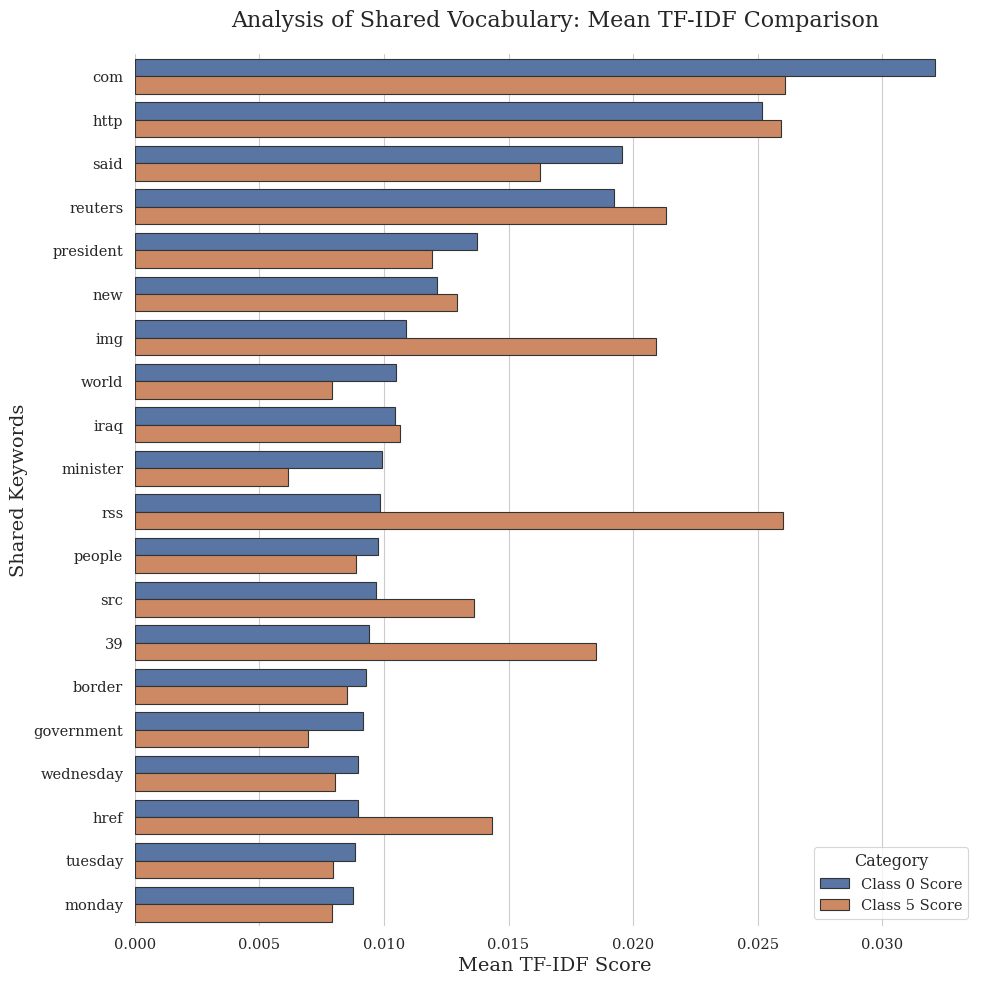

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurazione estetica accademica
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'

# 2. Definizione della tua palette colori
# Sostituisci i codici esadecimali con quelli della tua palette
my_palette = ["#4C72B0", "#DD8452"] 

# 3. Preparazione dati (Top 20 per leggibilità)
df_common_plot = pd.DataFrame(data).sort_values('Class 0 Score', ascending=False).head(20)

# 4. Trasformazione in "Long Format" per Seaborn
df_melted = df_common_plot.melt(id_vars='word', var_name='Class', value_name='Score')

# 5. Creazione del grafico
plt.figure(figsize=(10, 10))
ax = sns.barplot(
    data=df_melted, 
    y='word', 
    x='Score', 
    hue='Class', 
    palette=my_palette,
    edgecolor=".2"
)

# 6. Raffinatezze grafiche e labelling
plt.title('Analysis of Shared Vocabulary: Mean TF-IDF Comparison', fontsize=16, pad=20)
plt.xlabel('Mean TF-IDF Score', fontsize=14)
plt.ylabel('Shared Keywords', fontsize=14)
plt.legend(title='Category', frameon=True, loc='lower right')

# Pulizia dei bordi (Despine)
sns.despine(left=True, bottom=True)

plt.tight_layout()

# 7. Salvataggio in alta risoluzione
plt.savefig('final_img/academic_overlap_0_5_custom.pdf', format='pdf', bbox_inches='tight')
plt.savefig('final_img/academic_overlap_0_5_custom.png', dpi=300, bbox_inches='tight')
plt.show()

Training V20 for Confusion Matrix...


/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


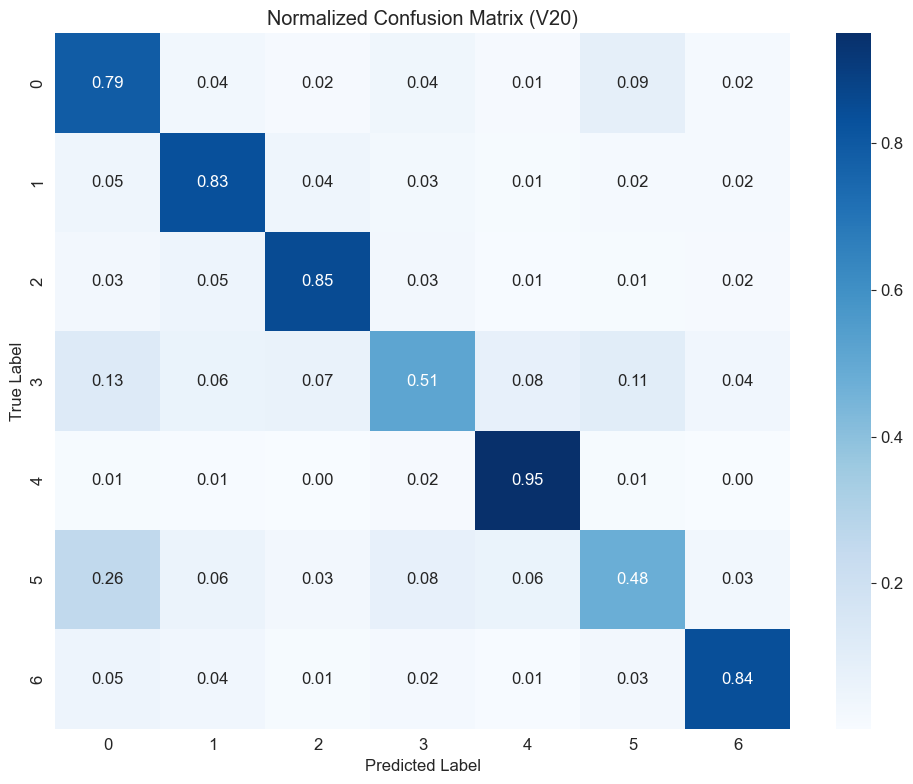

Confusion Matrix saved to final_img/


In [6]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Train Model (if not already in memory from previous cells)
# We assume 'pipe' from the previous cell is the V20 model
# If not, let's retrain a V20 instance quickly
print("Training V20 for Confusion Matrix...")
pipe_cm = get_v20_pipeline(alpha_val=1e-4) # Best alpha
pipe_cm.fit(X_train, y_train)
y_pred_cm = pipe_cm.predict(X_val)

# Compute CM
cm = confusion_matrix(y_val, y_pred_cm)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize by row

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=True,
            xticklabels=sorted(df['label'].unique()), 
            yticklabels=sorted(df['label'].unique()))
plt.title('Normalized Confusion Matrix (V20)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('final_img/plot_confusion_matrix.pdf', format='pdf', bbox_inches='tight')
plt.savefig('final_img/plot_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion Matrix saved to final_img/")
